# 🎬 TMDB Movies AI Agent — Groq

**Stack:** Python · Pandas · MySQL · LangChain · Groq (LLaMA 3.3 70B)

**Предполагается:** база `tmdb_movies` уже создана и данные загружены.



##  Install Dependencies

In [3]:
!pip install -q langchain langchain-groq langchain-community \
    groq pandas matplotlib seaborn pymysql sqlalchemy

## Configuration

In [ ]:

GROQ_API_KEY = "api"   # ← вставь свой Groq API key
GROQ_MODEL   = "llama-3.3-70b-versatile"

MYSQL_HOST     = "localhost"
MYSQL_PORT     = 3306
MYSQL_USER     = "root"
MYSQL_PASSWORD = "bread12345678"            # ← вставь свой пароль
MYSQL_DB       = "tmdb_moviess"

MOVIES_CSV  = "tmdb_5000_movies.csv"
CREDITS_CSV = "tmdb_5000_credits.csv"

import pandas as pd
from sqlalchemy import create_engine, text

DB_URL = f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}"
engine = create_engine(DB_URL, echo=False)

# Проверка подключения
try:
    with engine.connect() as conn:
        ver = conn.execute(text("SELECT VERSION()")).scalar()
    print(f"✅ MySQL {ver} — подключено к '{MYSQL_DB}'")
except Exception as e:
    print(f"❌ Ошибка подключения: {e}")


✅ MySQL 8.0.45 — подключено к 'tmdb_moviess'


##  Verify Schema

In [10]:
from sqlalchemy import inspect

def run_query(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

inspector = inspect(engine)
print(f"📊 Database: {MYSQL_DB}\n")
for table in inspector.get_table_names():
    cols  = [c['name'] for c in inspector.get_columns(table)]
    count = run_query(f"SELECT COUNT(*) as n FROM `{table}`")['n'][0]
    print(f"  🔷 {table:<25} {count:>7} rows | columns: {', '.join(cols)}")


📊 Database: tmdb_moviess

  🔷 cast_members                61228 rows | columns: id, movie_id, person_id, name, characters, cast_order, gender
  🔷 crew_members                54065 rows | columns: id, movie_id, person_id, name, department, job, gender
  🔷 genres                         20 rows | columns: genre_id, genre_name
  🔷 keywords                     9813 rows | columns: keyword_id, keyword_name
  🔷 movie_companies             13677 rows | columns: movie_id, company_id
  🔷 movie_genres                12160 rows | columns: movie_id, genre_id
  🔷 movie_keywords              36194 rows | columns: movie_id, keyword_id
  🔷 movies                       4803 rows | columns: movie_id, title, original_title, original_language, overview, tagline, status, homepage, budget, revenue, runtime, popularity, vote_average, vote_count, vote_weighted, release_date, release_year, release_month, profit, roi
  🔷 production_companies         5047 rows | columns: company_id, company_name


##  Build AI Agent (LangChain + Groq)

Используем `ChatGroq` + `create_sql_agent` — агент умеет:
- писать SQL-запросы к MySQL
- интерпретировать результаты
- отвечать на вопросы на естественном языке (рус/eng)

> **Автоматизация:** функция `ask_agent()` поддерживает любой вопрос — агент сам строит SQL, выполняет, форматирует ответ.

In [11]:
from langchain_groq import ChatGroq
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import create_sql_agent

# ── LLM
llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model_name=GROQ_MODEL,
    temperature=0,
    timeout=30,
    max_retries=2,
)

# ── Connect to DB
db = SQLDatabase.from_uri(DB_URL)
print("📊 Tables visible to agent:", db.get_usable_table_names())

# ── System prompt for the agent
PREFIX = """
You are an expert Movie Data Analyst AI assistant connected to a TMDB Movies MySQL database.

Schema overview:
  movies           : movie_id, title, original_title, original_language, overview, tagline,
                     status, homepage, budget, revenue, runtime, popularity,
                     vote_average, vote_count, vote_weighted, release_date,
                     release_year, release_month, profit, roi
  genres           : genre_id, genre_name
  keywords         : keyword_id, keyword_name
  production_companies : company_id, company_name
  movie_genres     : movie_id, genre_id        (many-to-many bridge)
  movie_keywords   : movie_id, keyword_id      (many-to-many bridge)
  movie_companies  : movie_id, company_id      (many-to-many bridge)
  cast_members     : id, movie_id, person_id, name, character, cast_order, gender
  crew_members     : id, movie_id, person_id, name, department, job, gender

Rules:
1. Always JOIN through bridge tables when needed.
2. For financial analysis use profit and roi columns (already computed).
3. For fair rating comparison use vote_weighted (Bayesian score).
4. Include numbers, rankings, and percentages in answers.
5. End every answer with a short insight or recommendation.
6. Answer in the same language the user asks (Russian or English).
7. Directors are in crew_members WHERE job = 'Director'.
"""

# ── Create the SQL agent
agent = create_sql_agent(
    llm=llm,
    db=db,
    agent_type="openai-tools",
    verbose=True,
    prefix=PREFIX,
    handle_parsing_errors=True,
    max_iterations=15,
)

def ask_agent(question: str) -> str:
    """Ask the agent a question in natural language (RU or EN)."""
    print(f"\n{'='*65}")
    print(f"❓ {question}")
    print('='*65)
    response = agent.invoke({"input": question})
    answer = response.get("output", str(response))
    print(f"\n💡 Answer:\n{answer}")
    return answer

print("\n✅ AI Agent (Groq) is ready!")

📊 Tables visible to agent: ['cast_members', 'crew_members', 'genres', 'keywords', 'movie_companies', 'movie_genres', 'movie_keywords', 'movies', 'production_companies']

✅ AI Agent (Groq) is ready!


##  Готовые вопросы к агенту

In [12]:
ask_agent("What are the top 10 highest grossing movies of all time? Show title, revenue and release year.")


❓ What are the top 10 highest grossing movies of all time? Show title, revenue and release year.


> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{'tool_input': ''}`
responded:   Then I should check my query before running it to make sure it is correct.  Then I should run the query to get the answer.



cast_members, crew_members, genres, keywords, movie_companies, movie_genres, movie_keywords, movies, production_companies
Invoking: `sql_db_schema` with `{'table_names': 'movies, genres, keywords, production_companies, movie_genres, movie_keywords, movie_companies, cast_members, crew_members'}`
responded:   Then I should check my query before running it to make sure it is correct.  Then I should run the query to get the answer.




CREATE TABLE cast_members (
	id INTEGER NOT NULL AUTO_INCREMENT, 
	movie_id INTEGER, 
	person_id INTEGER, 
	name VARCHAR(300), 
	characters TEXT, 
	cast_order TINYINT, 
	gender TINYINT, 
	PRIMARY KEY (id), 
	CONSTRAINT cast_

"The top 10 highest grossing movies of all time are:\n\n1. Avatar (2009) - $2,787,965,087\n2. Titanic (1997) - $1,845,034,188\n3. The Avengers (2012) - $1,519,557,910\n4. Jurassic World (2015) - $1,523,528,810\n5. Furious 7 (2015) - $1,505,249,360\n6. Avengers: Age of Ultron (2015) - $1,405,403,694\n7. Frozen (2013) - $1,274,219,009\n8. Iron Man 3 (2013) - $1,215,439,994\n9. Minions (2015) - $1,156,730,962\n10. Captain America: Civil War (2016) - $1,153,304,495\n\nThese movies have been incredibly successful at the box office, with Avatar being the highest grossing movie of all time. It's worth noting that these figures are subject to change over time and may not reflect the most up-to-date numbers."

In [ ]:
ask_agent("Какие жанры приносят наибольшую среднюю прибыль? Покажи топ 5 с числами.")


❓ Какие жанры приносят наибольшую среднюю прибыль? Покажи топ 5 с числами.


> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{'tool_input': ''}`
responded:   Then I should check my query to make sure it is correct.  Then I should run the query to get the answer.


cast_members, crew_members, genres, keywords, movie_companies, movie_genres, movie_keywords, movies, production_companies
Invoking: `sql_db_schema` with `{'table_names': 'movie_genres, genres, movies'}`
responded:   Then I should check my query to make sure it is correct.  Then I should run the query to get the answer.



CREATE TABLE genres (
	genre_id INTEGER NOT NULL, 
	genre_name VARCHAR(100) NOT NULL, 
	PRIMARY KEY (genre_id)
)COLLATE utf8mb4_0900_ai_ci DEFAULT CHARSET=utf8mb4 ENGINE=InnoDB

/*
3 rows from genres table:
genre_id	genre_name
12	Adventure
14	Fantasy
16	Animation
*/


CREATE TABLE movie_genres (
	movie_id INTEGER NOT NULL, 
	genre_id INTEGER NOT NULL, 
	PRIMARY KEY (movie_id

'Топ 5 жанров с наибольшей средней прибылью:\n\n1. Animation - 198 090 651 доллар\n2. Adventure - 170 714 153 доллара\n3. Fantasy - 162 675 510 долларов\n4. Family - 157 588 117 долларов\n5. Science Fiction - 125 956 782 доллара\n\nВнимание: эти цифры основаны на средней прибыли фильмов каждого жанра и могут не отражать фактическую прибыльность каждого отдельного фильма.\n\nРекомендация: если вы планируете инвестировать в производство фильмов, рассмотрите возможность инвестирования в анимационные или приключенческие фильмы, поскольку они имеют наибольшую среднюю прибыль. Однако, не забывайте учитывать другие факторы, такие как бюджет, аудитория и конкуренция на рынке.'

In [ ]:
ask_agent("Who are the top 10 most prolific directors? How many movies did each direct?")


❓ Who are the top 10 most prolific directors? How many movies did each direct?


> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`
responded:   Then I should check my query before running it to make sure it is correct.  Then I should run the query to get the answer.



cast_members, crew_members, genres, keywords, movie_companies, movie_genres, movie_keywords, movies, production_companies
Invoking: `sql_db_schema` with `{'table_names': 'crew_members,movie_genres,movie_keywords,movie_companies,cast_members,genres,keywords,production_companies,movies'}`
responded:   Then I should check my query before running it to make sure it is correct.  Then I should run the query to get the answer.




CREATE TABLE cast_members (
	id INTEGER NOT NULL AUTO_INCREMENT, 
	movie_id INTEGER, 
	person_id INTEGER, 
	name VARCHAR(300), 
	characters TEXT, 
	cast_order TINYINT, 
	gender TINYINT, 
	PRIMARY KEY (id), 
	CONSTRAINT cast_members_ibfk_1 FOREIGN KEY(movie_id) REFER

'The top 10 most prolific directors are:\n\n1. Steven Spielberg - 27 movies\n2. Woody Allen - 22 movies\n3. Martin Scorsese - 21 movies\n4. Clint Eastwood - 20 movies\n5. Robert Rodriguez - 17 movies\n6. Ridley Scott - 16 movies\n7. Spike Lee - 16 movies\n8. Steven Soderbergh - 15 movies\n9. Renny Harlin - 15 movies\n10. Oliver Stone - 14 movies\n\nInsight: These directors have had long and successful careers, with many of them having directed a wide range of films across different genres. Their prolific output is a testament to their dedication to their craft and their ability to consistently produce high-quality films.'

In [ ]:
ask_agent("Which movies have the highest ROI (return on investment)? Show top 10 with budget, revenue and ROI.")


❓ Which movies have the highest ROI (return on investment)? Show top 10 with budget, revenue and ROI.


> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{'tool_input': ''}`
responded:   Then I should check my query before running it to make sure it is correct.  Then I should run the query to get the answer.



cast_members, crew_members, genres, keywords, movie_companies, movie_genres, movie_keywords, movies, production_companies
Invoking: `sql_db_schema` with `{'table_names': 'movies, movie_genres, movie_keywords, movie_companies'}`
responded:   Then I should check my query before running it to make sure it is correct.  Then I should run the query to get the answer.




CREATE TABLE movie_companies (
	movie_id INTEGER NOT NULL, 
	company_id INTEGER NOT NULL, 
	PRIMARY KEY (movie_id, company_id), 
	CONSTRAINT movie_companies_ibfk_1 FOREIGN KEY(movie_id) REFERENCES movies (movie_id), 
	CONSTRAINT movie_companies_ibfk_2 FOREIGN KEY(company_id) REFERENCES 

"The top 10 movies with the highest ROI are:\n\n1. Modern Times - budget: $1, revenue: $8,500,000, ROI: $8,500,000\n2. Nurse 3-D - budget: $10, revenue: $10,000,000, ROI: $999,999\n3. Paranormal Activity - budget: $15,000, revenue: $193,355,800, ROI: 12,889.4\n4. Tarnation - budget: $218, revenue: $1,162,014, ROI: 5,329.34\n5. The Blair Witch Project - budget: $60,000, revenue: $248,000,000, ROI: 4,132.33\n6. Eraserhead - budget: $10,000, revenue: $7,000,000, ROI: 699\n7. Pink Flamingos - budget: $12,000, revenue: $6,000,000, ROI: 499\n8. Super Size Me - budget: $65,000, revenue: $28,575,078, ROI: 438.617\n9. The Gallows - budget: $100,000, revenue: $42,664,410, ROI: 425.644\n10. Open Water - budget: $130,000, revenue: $54,667,954, ROI: 419.523\n\nInsight: These movies have achieved high returns on investment, with some having ROI values in the thousands or even tens of thousands. This suggests that they were highly successful and profitable, despite having relatively low budgets. It's

In [ ]:
ask_agent("Какие актёры чаще всего снимаются в высокорейтинговых фильмах (vote_weighted > 7.5)? Топ 10.")


❓ Какие актёры чаще всего снимаются в высокорейтинговых фильмах (vote_weighted > 7.5)? Топ 10.


> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{'tool_input': ''}`
responded:   Then I should check my query before running it to make sure it is correct.  Then I should run the query to get the answer.



cast_members, crew_members, genres, keywords, movie_companies, movie_genres, movie_keywords, movies, production_companies
Invoking: `sql_db_schema` with `{'table_names': 'cast_members, movies, movie_genres, movie_keywords, movie_companies, genres, keywords, production_companies, crew_members'}`
responded:   Then I should check my query before running it to make sure it is correct.  Then I should run the query to get the answer.




CREATE TABLE cast_members (
	id INTEGER NOT NULL AUTO_INCREMENT, 
	movie_id INTEGER, 
	person_id INTEGER, 
	name VARCHAR(300), 
	characters TEXT, 
	cast_order TINYINT, 
	gender TINYINT, 
	PRIMARY KEY (id), 
	CONSTRAINT cast_me

'Актёры, которые чаще всего снимаются в высокорейтинговых фильмах (vote_weighted > 7.5), это:\n\n1. Харрисон Форд (6 фильмов)\n2. Леонардо Ди Каприо (6 фильмов)\n3. Мэтт Деймон (5 фильмов)\n4. Майкл Кейн (5 фильмов)\n5. Джеймс Эрл Джонс (5 фильмов)\n6. Хьюго Уивинг (5 фильмов)\n7. Том Хэнкс (5 фильмов)\n8. Морган Фриман (4 фильма)\n9. Энди Серкис (4 фильма)\n10. Джон Рис-Дэвис (4 фильма)\n\nЭти актёры снимались в фильмах, которые получили высокие оценки зрителей и критиков, и их участие в проектах часто является гарантией качества и успеха.'

In [ ]:
ask_agent("Which production company has the highest average revenue per movie? Show top 5 companies with at least 10 movies.")


❓ Which production company has the highest average revenue per movie? Show top 5 companies with at least 10 movies.


> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`
responded:   Then I should check my query before running it to make sure it is correct.  Then I should run the query to get the answer.



cast_members, crew_members, genres, keywords, movie_companies, movie_genres, movie_keywords, movies, production_companies
Invoking: `sql_db_schema` with `{'table_names': 'production_companies, movie_companies, movies'}`
responded:   Then I should check my query before running it to make sure it is correct.  Then I should run the query to get the answer.




CREATE TABLE movie_companies (
	movie_id INTEGER NOT NULL, 
	company_id INTEGER NOT NULL, 
	PRIMARY KEY (movie_id, company_id), 
	CONSTRAINT movie_companies_ibfk_1 FOREIGN KEY(movie_id) REFERENCES movies (movie_id), 
	CONSTRAINT movie_companies_ibfk_2 FOREIGN KEY(company_id) REFERENCES production

"The top 5 production companies with the highest average revenue per movie, with at least 10 movies, are Marvel Studios, WingNut Films, Heyday films, Pixar Animation Studios, and Revolution Sun Studios, with average revenues of $779,877,975.38, $643,763,863.82, $624,034,346.58, $613,112,049.25, and $517,989,606.06 respectively. \n\nIt's interesting to note that these companies have been able to consistently produce high-revenue movies, which could be due to their ability to create engaging stories, market their movies effectively, or a combination of both. This insight could be useful for investors or producers looking to partner with production companies that have a track record of success."

##  Dashboard Visualizations

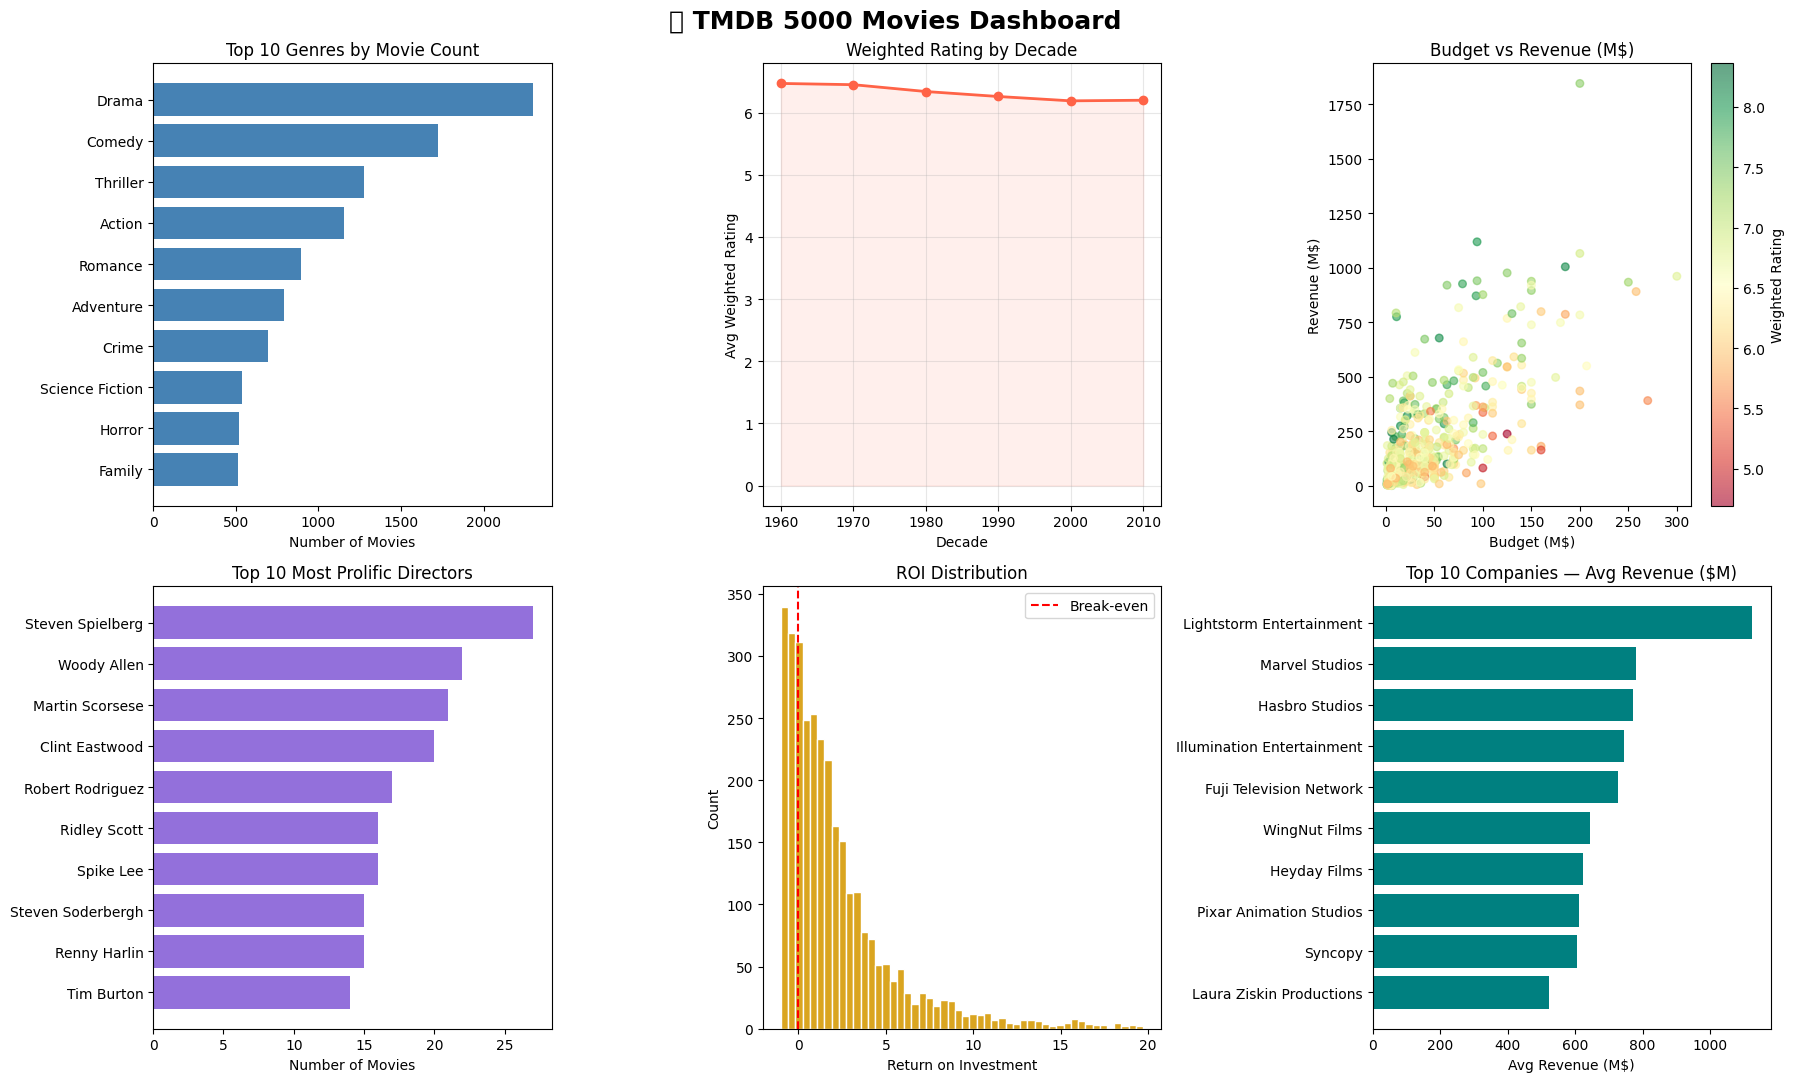

📊 Dashboard saved as tmdb_dashboard.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('🎬 TMDB 5000 Movies Dashboard', fontsize=18, fontweight='bold')

# Chart 1 — Top 10 genres by movie count
df1 = run_query("""
    SELECT g.genre_name, COUNT(*) as movie_count
    FROM movie_genres mg
    JOIN genres g ON mg.genre_id = g.genre_id
    GROUP BY g.genre_name
    ORDER BY movie_count DESC LIMIT 10
""")
axes[0,0].barh(df1['genre_name'], df1['movie_count'], color='steelblue')
axes[0,0].set_title('Top 10 Genres by Movie Count')
axes[0,0].set_xlabel('Number of Movies')
axes[0,0].invert_yaxis()

# Chart 2 — Average vote_weighted by decade
df2 = run_query("""
    SELECT FLOOR(release_year/10)*10 AS decade,
           ROUND(AVG(vote_weighted),2) AS avg_rating,
           COUNT(*) as movie_count
    FROM movies
    WHERE release_year IS NOT NULL AND release_year >= 1960
    GROUP BY decade ORDER BY decade
""")
axes[0,1].plot(df2['decade'], df2['avg_rating'], marker='o', color='tomato', linewidth=2)
axes[0,1].fill_between(df2['decade'], df2['avg_rating'], alpha=0.1, color='tomato')
axes[0,1].set_title('Weighted Rating by Decade')
axes[0,1].set_xlabel('Decade')
axes[0,1].set_ylabel('Avg Weighted Rating')
axes[0,1].grid(True, alpha=0.3)

# Chart 3 — Budget vs Revenue scatter
df3 = run_query("""
    SELECT budget, revenue, vote_weighted
    FROM movies
    WHERE budget IS NOT NULL AND revenue IS NOT NULL
      AND budget > 1000000 AND revenue > 1000000
    LIMIT 500
""")
scatter = axes[0,2].scatter(
    df3['budget']/1e6, df3['revenue']/1e6,
    c=df3['vote_weighted'], cmap='RdYlGn', alpha=0.6, s=30
)
plt.colorbar(scatter, ax=axes[0,2], label='Weighted Rating')
axes[0,2].set_title('Budget vs Revenue (M$)')
axes[0,2].set_xlabel('Budget (M$)')
axes[0,2].set_ylabel('Revenue (M$)')

# Chart 4 — Top 10 directors by movie count
df4 = run_query("""
    SELECT name, COUNT(DISTINCT movie_id) as movies
    FROM crew_members
    WHERE job = 'Director'
    GROUP BY name ORDER BY movies DESC LIMIT 10
""")
axes[1,0].barh(df4['name'], df4['movies'], color='mediumpurple')
axes[1,0].set_title('Top 10 Most Prolific Directors')
axes[1,0].set_xlabel('Number of Movies')
axes[1,0].invert_yaxis()

# Chart 5 — ROI distribution
df5 = run_query("""
    SELECT roi FROM movies
    WHERE roi IS NOT NULL AND roi BETWEEN -1 AND 20
""")
axes[1,1].hist(df5['roi'], bins=50, color='goldenrod', edgecolor='white')
axes[1,1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[1,1].set_title('ROI Distribution')
axes[1,1].set_xlabel('Return on Investment')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

# Chart 6 — Top 10 companies by avg revenue
df6 = run_query("""
    SELECT pc.company_name,
           ROUND(AVG(m.revenue)/1e6, 1) as avg_revenue_m,
           COUNT(*) as movies
    FROM movie_companies mc
    JOIN production_companies pc ON mc.company_id = pc.company_id
    JOIN movies m ON mc.movie_id = m.movie_id
    WHERE m.revenue IS NOT NULL
    GROUP BY pc.company_name
    HAVING movies >= 5
    ORDER BY avg_revenue_m DESC LIMIT 10
""")
bars = axes[1,2].barh(df6['company_name'], df6['avg_revenue_m'], color='teal')
axes[1,2].set_title('Top 10 Companies — Avg Revenue ($M)')
axes[1,2].set_xlabel('Avg Revenue (M$)')
axes[1,2].invert_yaxis()

plt.tight_layout()
plt.savefig('tmdb_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Dashboard saved as tmdb_dashboard.png")

## Interactive Chat

Задавай вопросы на русском или английском языке.

In [14]:
import ipywidgets as widgets
from IPython.display import display, clear_output

output = widgets.Output()
text_input = widgets.Text(
    placeholder='Задай вопрос на русском или английском...',
    layout=widgets.Layout(width='70%')
)
send_btn = widgets.Button(
    description='Спросить ▶',
    button_style='primary',
    layout=widgets.Layout(width='120px')
)
clear_btn = widgets.Button(
    description='Очистить',
    button_style='warning',
    layout=widgets.Layout(width='100px')
)

def on_send(b):
    question = text_input.value.strip()
    if not question:
        return
    text_input.value = ''
    with output:
        ask_agent(question)

def on_clear(b):
    output.clear_output()

send_btn.on_click(on_send)
clear_btn.on_click(on_clear)

# Also send on Enter key
def on_submit(widget):
    on_send(None)
text_input.on_submit(on_submit)

print("🤖 TMDB Movies AI Agent (Groq) — готов к работе!")
print("Примеры: 'Топ 10 фильмов по сборам', 'Какой режиссёр снял больше всего фильмов?'")
display(widgets.HBox([text_input, send_btn, clear_btn]))
display(output)


🤖 TMDB Movies AI Agent (Groq) — готов к работе!
Примеры: 'Топ 10 фильмов по сборам', 'Какой режиссёр снял больше всего фильмов?'


Output()

##  Incremental Update (Автоматизация)

Запускай этот блок, когда появятся новые CSV — пайплайн автоматически загрузит **только новые** фильмы.

In [ ]:
# ── Incremental run: collect → transform → load
# collect_data уже умеет определять какие movie_id есть в DB
# и пропускать уже загруженные фильмы.

import importlib
importlib.reload(collect_data)
importlib.reload(transform_data)
importlib.reload(load_to_mysql)

print("🔄 Running incremental ETL pipeline...\n")

# Step 1 — только новые фильмы попадут в raw_tmdb_data.csv
collect_data.collect_data()

# Step 2 — трансформируем только новые
transform_data.transform_data()

# Step 3 — дозагружаем в MySQL
load_to_mysql.load_to_mysql()

print("\n✅ Incremental update complete!")